# Day 11: LSTM & GRU for Text Classification (Sarcasm Detection)

## 1. Data Loading & Initial Inspection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models

url = "https://raw.githubusercontent.com/Vvijayaragupathy-uno/machinelearning/main/day10/Sarcasm_Headlines_Dataset_v2_backup.json"
data = pd.read_json(url, lines=True)

# Inspect the dataset
print("Data Info:")
data.info()
print("\nFirst 5 rows:")
print(data.head())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB

First 5 rows:
   is_sarcastic                                           headline  \
0             1  thirtysomething scientists unveil doomsday clo...   
1             0  dem rep. totally nails why congress is falling...   
2             0  eat your veggies: 9 deliciously different recipes   
3             1  inclement weather prevents liar from getting t...   
4             1  mother comes pretty close to using word 'strea...   

                                        article_link  
0  https://www.theonion.com/thirtysomething-scien...  
1  https://www.huffingtonpost.com/entry/donna-edw...  
2  https://www.huf

## 2. Missing Values, Duplicates & Outliers


In [2]:
print("Missing Values before cleaning:\n", data.isnull().sum())

# Check for duplicates
duplicates = data.duplicated().sum()
print(f"\nFound {duplicates} duplicate rows. Dropping them...")

# Drop duplicates
data = data.drop_duplicates()

# Drop unnecessary column
data = data.drop(columns=['article_link'])

print("Data Shape after cleaning:", data.shape)

Missing Values before cleaning:
 is_sarcastic    0
headline        0
article_link    0
dtype: int64

Found 2 duplicate rows. Dropping them...
Data Shape after cleaning: (28617, 2)


## 3. Feature Engineering


In [3]:
# Create character count feature
data['char_count'] = data['headline'].apply(len)

# Create word count feature (by splitting on whitespace)
data['word_count'] = data['headline'].apply(lambda x: len(x.split()))

print("Max Word Count:", data['word_count'].max())
print("99th Percentile Word Count:", np.percentile(data['word_count'], 99))

Max Word Count: 151
99th Percentile Word Count: 19.0


## 4. Exploratory Data Analysis (EDA)


/tmp/ipykernel_1417/342290359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='is_sarcastic', palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_1417/342290359.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='is_sarcastic', y='word_count', palette='viridis', ax=axes[1, 0])


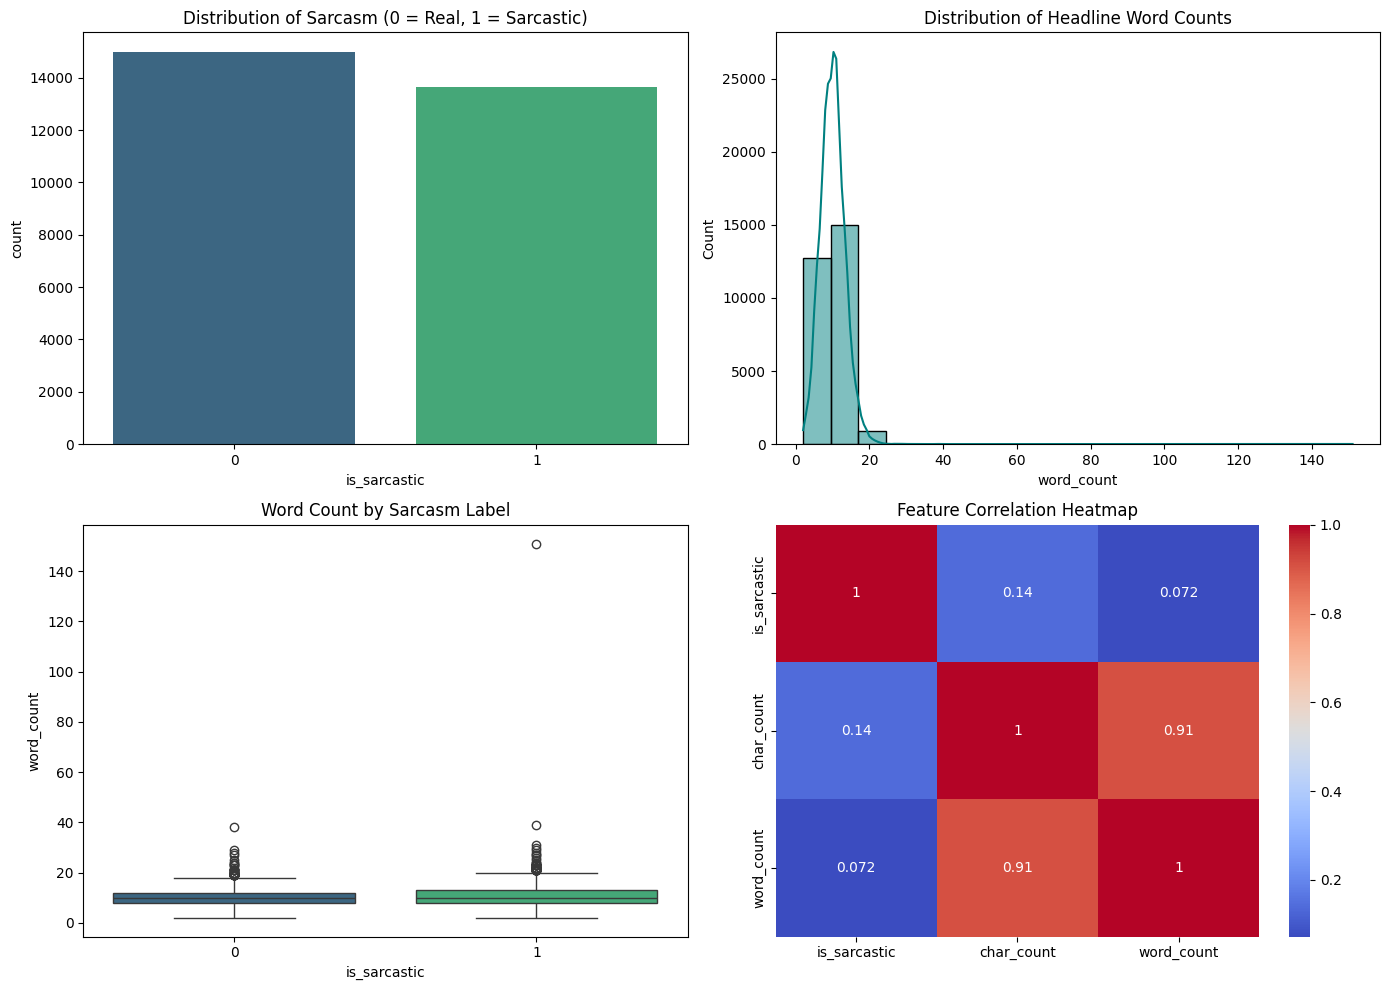

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Class Distribution
sns.countplot(data=data, x='is_sarcastic', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Sarcasm (0 = Real, 1 = Sarcastic)')

# Chart 2: Histogram of Word Count
sns.histplot(data=data, x='word_count', bins=20, kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Headline Word Counts')

# Chart 3: Boxplot of Word Count vs Sarcasm
sns.boxplot(data=data, x='is_sarcastic', y='word_count', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Word Count by Sarcasm Label')

# Chart 4: Correlation Heatmap
sns.heatmap(data[['is_sarcastic', 'char_count', 'word_count']].corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 5. Key Insights


## 6. Preprocessing for the Neural Network


In [5]:
X_text = data['headline'].values
y = data['is_sarcastic'].values

# 1. Initialize the Tokenizer to keep only the top 5000 words
tokenizer = Tokenizer(num_words=5000)

# 2. 'Fit' the tokenizer on our text so it learns the vocabulary
tokenizer.fit_on_texts(X_text)

# 3. Convert sentences to sequences of integers
X_seq = tokenizer.texts_to_sequences(X_text)

# 4. Pad or Truncate all sequences to exactly 50 tokens
X_padded = pad_sequences(X_seq, maxlen=50)

print("Original Text:", X_text[0])
print("Integer Sequence Length:", len(X_seq[0]))
print("Padded Sequence Length:", len(X_padded[0]))
print("\nPadded Array:\n", X_padded[0])

Original Text: thirtysomething scientists unveil doomsday clock of hair loss
Integer Sequence Length: 6
Padded Sequence Length: 50

Padded Array:
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0  354 3166 2643    2  660 1118]


## 7. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22893
Testing samples: 5724


## 8. Build the Long Short-Term Memory (LSTM) Model


In [7]:
lstm_model = models.Sequential([
    layers.Input(shape=(50,)),
    
    # Embedding Layer
    layers.Embedding(5000, 32),
    
    # Dropout Layer to prevent overfitting
    layers.Dropout(0.4),
    
    # LSTM Layer (Replacing SimpleRNN)
    layers.LSTM(32, dropout=0.4),
    
    # Dense Output Layer
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,353 (657.63 KB)

 Trainable params: 168,353 (657.63 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train and Evaluate the LSTM

In [8]:
# Train for 5 epochs
lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs=5, 
    validation_data=(X_test, y_test)
)

# Get the final test accuracy
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal LSTM Test Accuracy: {lstm_accuracy * 100:.2f}%\n")

Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.7757 - loss: 0.4608 - val_accuracy: 0.8412 - val_loss: 0.3544
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.8655 - loss: 0.3176 - val_accuracy: 0.8457 - val_loss: 0.3403
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.8820 - loss: 0.2834 - val_accuracy: 0.8505 - val_loss: 0.3435
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.8941 - loss: 0.2574 - val_accuracy: 0.8470 - val_loss: 0.3457
Epoch 5/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9025 - loss: 0.2383 - val_accuracy: 0.8498 - val_loss: 0.3541

Final LSTM Test Accuracy: 84.98%



## 10.  Build the Gated Recurrent Unit (GRU) Model


In [10]:
gru_model = models.Sequential([
    layers.Input(shape=(50,)),
    
    # Embedding Layer
    layers.Embedding(5000, 32),
    
    # Dropout Layer to prevent overfitting
    layers.Dropout(0.4),
    
    # GRU Layer (Replacing LSTM)
    layers.GRU(32, dropout=0.4),
    
    # Dense Output Layer
    layers.Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Train and Evaluate the GRU

In [11]:
# Train for 5 epochs
gru_history = gru_model.fit(
    X_train, y_train, 
    epochs=5, 
    validation_data=(X_test, y_test)
)

# Get the final test accuracy
gru_loss, gru_accuracy = gru_model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal GRU Test Accuracy: {gru_accuracy * 100:.2f}%\n")

Epoch 1/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7662 - loss: 0.4632 - val_accuracy: 0.8382 - val_loss: 0.3525
Epoch 2/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8654 - loss: 0.3178 - val_accuracy: 0.8424 - val_loss: 0.3409
Epoch 3/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.8808 - loss: 0.2835 - val_accuracy: 0.8498 - val_loss: 0.3392
Epoch 4/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.8933 - loss: 0.2598 - val_accuracy: 0.8496 - val_loss: 0.3429
Epoch 5/5
716/716 ━━━━━━━━━━━━━━━━━━━━ 25s 35ms/step - accuracy: 0.9015 - loss: 0.2416 - val_accuracy: 0.8526 - val_loss: 0.3561

Final GRU Test Accuracy: 85.26%



## 12. Plot LSTM vs GRU Performance

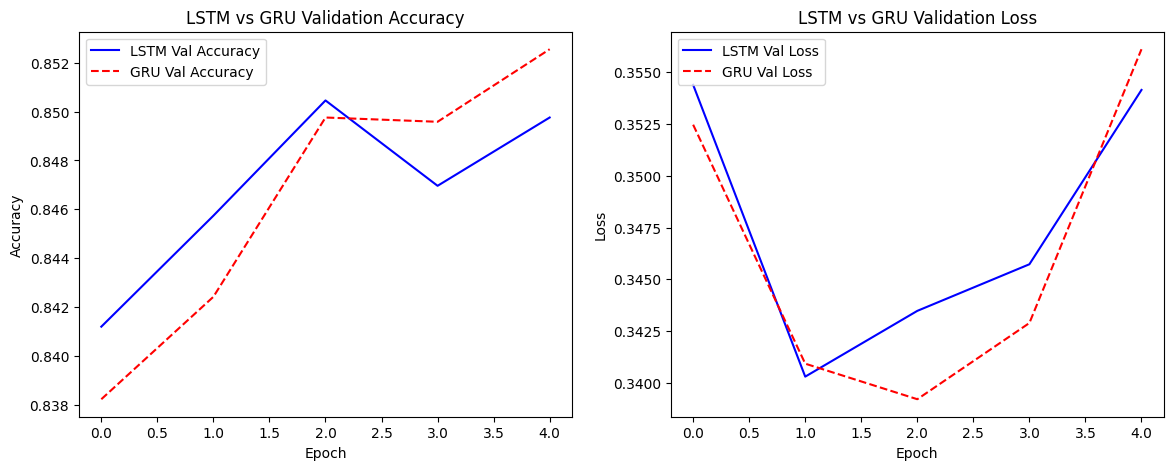

In [12]:
# Plot the training vs validation accuracy and loss for both models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(lstm_history.history['val_accuracy'], label='LSTM Val Accuracy', color='blue')
ax1.plot(gru_history.history['val_accuracy'], label='GRU Val Accuracy', color='red', linestyle='--')
ax1.set_title('LSTM vs GRU Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(lstm_history.history['val_loss'], label='LSTM Val Loss', color='blue')
ax2.plot(gru_history.history['val_loss'], label='GRU Val Loss', color='red', linestyle='--')
ax2.set_title('LSTM vs GRU Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

## 13.What does the forget gate let an LSTM do that a plain RNN cannot?**
*The forget gate allows an LSTM to look at a sequence and decide exactly which pieces of information from the past are irrelevant and should be discarded, while preserving important long-term context in its internal cell state. This prevents the "vanishing gradient" problem that plagues plain RNNs by providing a clean, uninterrupted path for critical information to flow across very long sentences.*
